In [4]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

In [5]:
bids_folder_subjects = '/mnt_03/ds-dnumrisk' 
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
target_dir = op.join(bids_folder_matrices,'derivatives','gradients.glmsingle')
os.makedirs(target_dir, exist_ok=True)

subList = [f[4:6] for f in os.listdir(bids_folder_subjects) if f[0:4] == 'sub-' and len(f) == 6]

# group list
#df_participants = pd.read_csv(op.join(bids_folder_subjects, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
#group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')

source_folder = op.join(bids_folder_matrices,'derivatives','correlation_matrices.glmsingle')
target_folder = op.join(bids_folder_matrices,'derivatives','gradients.glmsingle')

specification = '' # align_spec = '_align-procrustes'
ses = 1

In [6]:
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [4]:
# Compute average correlation matrix for all subjects for each stimulus type
group = 'All'

stimuli_types = ['1', '2']

for stimulus in stimuli_types:
    print(f'Processing {stimulus}...')
    
    # Initialize zero matrix for averaging
    matrix_zeros = np.zeros((N_vertices, N_vertices))
    av_cm = matrix_zeros.copy()

    for sub in subList:
        try:
            # Load the correlation matrix for the current stimulus type
            correlation_matrix = np.load(op.join(
                source_folder,
                f'sub-{sub}_ses-{ses}_stimulus-{stimulus}_betas_space-fsav5.npy'
            ))
            av_cm += np.arctan(correlation_matrix)  # Fisher Z-transformation
            print(f'Subject {sub} added for {stimulus}')
        except Exception as e:
            print(f'Subject {sub} failed for {stimulus}: {e}')

    # Compute the average correlation matrix
    av_cm = av_cm / len(subList)
    av_cm_transf = np.tan(av_cm)  # Sanity check: diagonal should be 1!

    # Save the average correlation matrix for the current stimulus type
    np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle.npy'), av_cm_transf)
    print(f'Average correlation matrix saved for stimulus {stimulus}')

Processing 1...
Subject 21 added for 1
Subject 59 added for 1
Subject 54 added for 1
Subject 15 added for 1
Subject 52 added for 1
Subject 08 added for 1
Subject 57 added for 1
Subject 50 added for 1
Subject 36 added for 1
Subject 56 added for 1
Subject 02 added for 1
Subject 22 added for 1
Subject 01 added for 1
Subject 19 added for 1
Subject 23 added for 1
Subject 06 added for 1
Subject 18 added for 1
Subject 13 added for 1
Subject 03 failed for 1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/correlation_matrices.glmsingle/sub-03_ses-1_stimulus-1_betas_space-fsav5.npy'
Subject 31 added for 1
Subject 55 added for 1
Subject 41 added for 1
Subject 65 added for 1
Subject 49 added for 1
Subject 29 added for 1
Subject 34 added for 1
Subject 17 added for 1
Subject 27 added for 1
Subject 30 added for 1
Subject 51 added for 1
Subject 20 added for 1
Subject 66 added for 1
Subject 24 added for 1
Subject 46 added for 1
Subject 39 ad

Shape: (18715, 18715)
Type: <class 'numpy.ndarray'>
[[ 1.0000000e+00  3.0274171e-02  2.2552323e-01 ... -4.4118207e-02
   5.9500281e-02  1.8616466e-02]
 [ 3.0274171e-02  1.0000000e+00 -6.9067992e-02 ... -8.1361853e-02
  -9.1506056e-03 -2.0958502e-02]
 [ 2.2552323e-01 -6.9067985e-02  1.0000000e+00 ... -1.4924243e-02
   1.8369649e-02  1.5522975e-02]
 ...
 [-4.4118207e-02 -8.1361853e-02 -1.4924243e-02 ...  1.0000000e+00
   6.8925455e-02 -9.2026475e-04]
 [ 5.9500284e-02 -9.1506056e-03  1.8369649e-02 ...  6.8925455e-02
   1.0000000e+00  2.3492290e-01]
 [ 1.8616466e-02 -2.0958502e-02  1.5522975e-02 ... -9.2026475e-04
   2.3492290e-01  1.0000000e+00]]


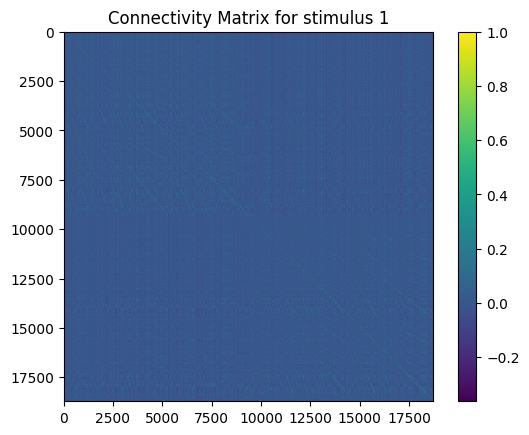

In [ ]:
import numpy as np
import os.path as op
import matplotlib.pyplot as plt

# Example subject and stimulus
sub = 'All'
stim = '1'

source_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/correlation_matrices.glmsingle'

# File path
file_path = op.join(source_folder, f'sub-{sub}_ses-1_stimulus-{stim}_betas_space-fsav5.npy')

# Load the connectivity matrix
connectivity_matrix = np.load(file_path, allow_pickle=True)

# Print basic information
print(f"Shape: {connectivity_matrix.shape}") # 18715, 18715
print(f"Type: {type(connectivity_matrix)}")
print(connectivity_matrix)

# Visualize the matrix
plt.imshow(connectivity_matrix, cmap='viridis')
plt.colorbar()
plt.title(f'Connectivity Matrix for stimulus {stim}')
plt.show()

In [13]:
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()

sub = 'All'
stimulus = '2'

n_components = 10 # reference gradient only has 3 components anyway... for better alignment one needs more components?! (according to Alam, 2022, L-R GM differences & cognition )

av_cm = np.load(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle.npy'))

target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}')
if not op.exists(target_dir):
    os.makedirs(target_dir)

# load in reference gradient and apply same filter
g_ref = np.load(op.join(bids_folder_subjects,'derivatives', 'gradients','sub-All/sub-All_gradients_N-10.npy')) # same labeling_noParcel as cm_unfiltered
g_ref = g_ref[:, mask] #

# now perform embedding on cleaned data + alignment
print(f'start fitting gradintes now')
gm = GradientMaps(n_components=n_components, alignment='procrustes') # defaults: approacch = 'dm', kernel = None
gm.fit(av_cm,reference=g_ref.T)
print(f'finished stimulus_{stimulus}: gradients generated')

np.save(op.join(target_dir,f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy'), grad) # save all together
gm_ = gm.aligned_.T
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_g-aligned_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy'), grad) # save all together 

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
start fitting gradintes now
finished stimulus_2: gradients generated


In [11]:
#g_ref.shape
av_cm.shape

(18715, 18715)

In [25]:
sub = 'All'
stimulus = '2'
spec = 'g-aligned'  #gradients
target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}')

grad = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy'))

Text(0.5, 0.9, 'stimulus 2 - g-aligned')

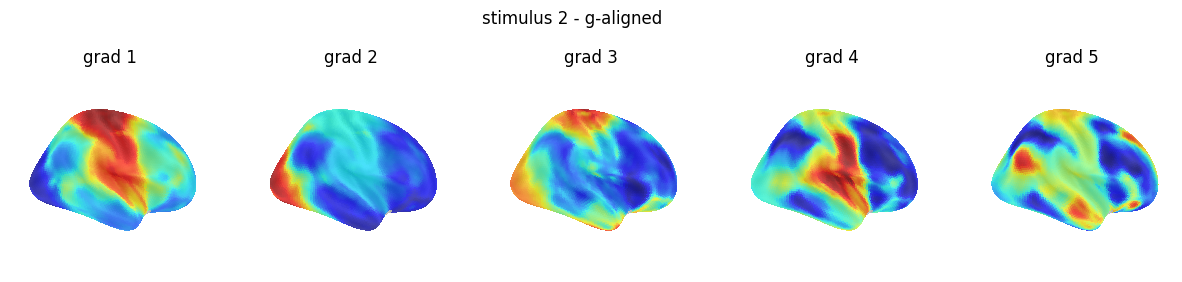

In [26]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=1, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))
for i in range(0,n_comp):
    gm = np.split(grad[i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
    gm_r = gm[1]
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[i]) #
    axes[i].set(title=f'grad {i+1}')
figure.suptitle(f'stimulus {stimulus} - {spec}', y=0.9)

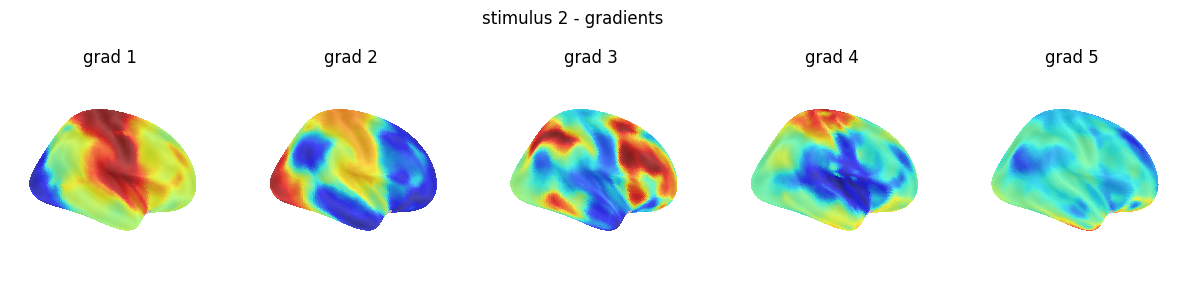

In [21]:
# code to flip grad 1 for stim_1 

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_surf_fsaverage

fsaverage = fetch_surf_fsaverage()  # default fsaverage5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=1, ncols=n_comp, figsize=(15, 4), subplot_kw=dict(projection='3d'))
for i in range(0, n_comp):
    # Flip grad 1 values if i == 0
    grad_to_plot = -grad[i] if i == 0 else grad[i]
    
    # Split into left and right hemispheres
    gm = np.split(grad_to_plot, 2)  # Left first, then right
    gm_r = gm[1]
    
    # Plot the right hemisphere
    nplt.plot_surf(
        surf_mesh=fsaverage.infl_right, surf_map=gm_r,  # infl_right or pial_right
        view=side_view, cmap=cmap, colorbar=False,
        bg_map=fsaverage.sulc_right, bg_on_data=True, darkness=0.7, axes=axes[i]
    )
    axes[i].set(title=f'grad {i+1}')

figure.suptitle(f'stimulus {stimulus} - {spec}', y=0.9)
plt.show()

In [28]:
# plot lambdas

from kneed import KneeLocator #  knee point is the point of maximum curvature.

sub = 'All'
n_comp=10
stimuli_types = ['1', '2']

# Loop through each stimulus
for stimulus in stimuli_types:
    print(f"Processing {stimulus}...")

    fn_lambdas = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}',f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy')
    lambdas = np.load(fn_lambdas)
    
    # Find the knee point
    kneedle = KneeLocator(x=range(1, len(lambdas) + 1), y=lambdas, S=1.0, curve="convex", direction="decreasing")
    
    # Plot the knee
    plt.figure()
    kneedle.plot_knee()
    plt.title(f"Knee Plot for {stimulus}")
    plt.xlabel("Component")
    plt.ylabel("Lambda")

    # Save the plot
    output_plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}_betas.png')
    plt.savefig(output_plot_path)
    plt.close()
    print(f"Saved knee plot for {stimulus} at {output_plot_path}")

Processing 1...
Saved knee plot for 1 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_1/sub-All_knee_plot_1_betas.png
Processing 2...
Saved knee plot for 2 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_2/sub-All_knee_plot_2_betas.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

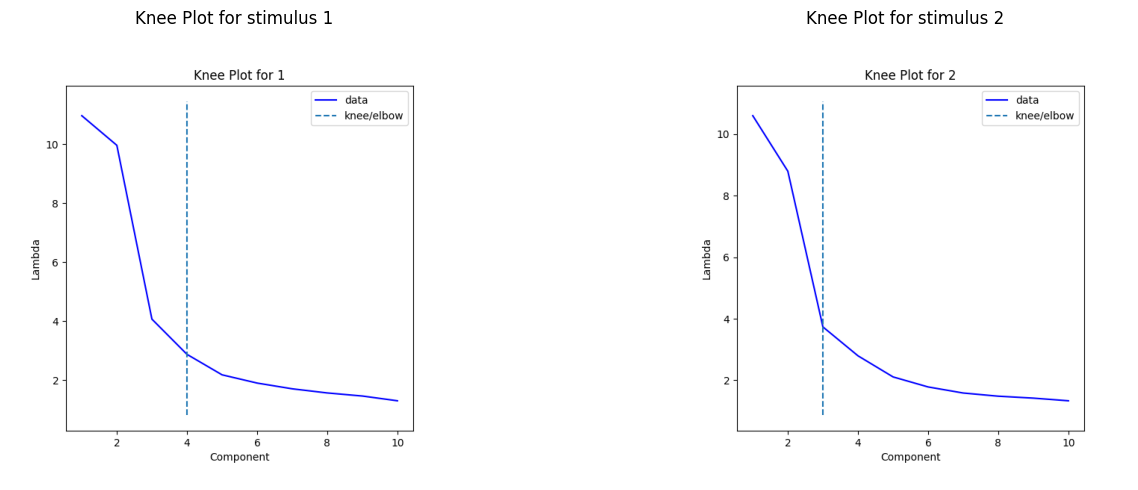

In [30]:
import matplotlib.pyplot as plt
import os.path as op

# Parameters
sub = 'All'
stimuli_types = ['1', '2']

# Initialize figure for side-by-side visualization
fig, axes = plt.subplots(1, len(stimuli_types), figsize=(15, 5))  # 1 row, 3 columns

# Loop through each stimulus to load and display the saved plots
for i, stimulus in enumerate(stimuli_types):
    # File path to the saved plot
    plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}_betas.png')
    
    # Load and display the saved plot
    img = plt.imread(plot_path)
    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')  # Turn off axes for better visualization
    ax.set_title(f"Knee Plot for stimulus {stimulus}")

# Adjust layout and show the combined visualization
plt.tight_layout()
plt.show()

Processing comparison: stimulus 1 vs stimulus 2...
Correlation Matrix for 1 vs 2:
[[0.99603095 0.15259717 0.00519985 0.49257325 0.11525964]
 [0.15392174 0.99535514 0.47255909 0.19236825 0.03584013]
 [0.01908942 0.49555236 0.98899353 0.2559499  0.23989742]
 [0.48777819 0.203557   0.2342287  0.99486972 0.31288861]
 [0.10392541 0.02303733 0.23026164 0.28952345 0.99218454]]


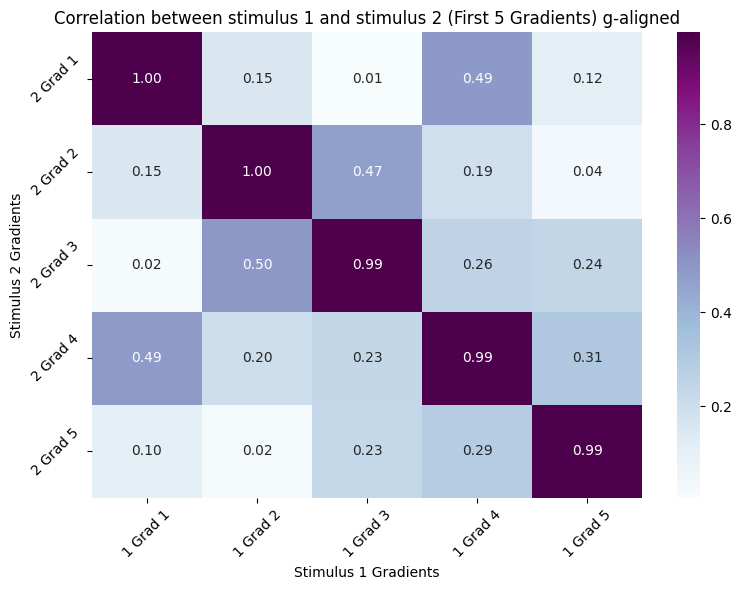

In [34]:
# plot correlation matrix checking similarity between stim 1 and stim 2, stim 1 and remaining, stim 2 and remaining

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt

# Parameters
sub = 'All'
spec = 'g-aligned'  # gradients
stimuli_pairs = [
    ('1', '2')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: stimulus {stim1} vs stimulus {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}_betas.npy')
    grad2_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim2}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim2}_betas.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients
    
    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between stimulus {stim1} and stimulus {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"Stimulus {stim1} Gradients")
    plt.ylabel(f"Stimulus {stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [7]:
from my_utils import get_glasser_parcels, get_glasser_CAatlas_mapping
import os
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns

rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

# Update the function to use the correct path
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser
)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [8]:
CAatlas_names['Network Name']

Label Number
1                  Visual1
2                  Visual2
3              Somatomotor
4        Cingulo-Opercular
5         Dorsal-attention
6                 Language
7           Frontoparietal
8                 Auditory
9                  Default
10    Posterior-Multimodal
11      Ventral-Multimodal
12        Orbito-Affective
Name: Network Name, dtype: object

Processing 1...
Processing 2...


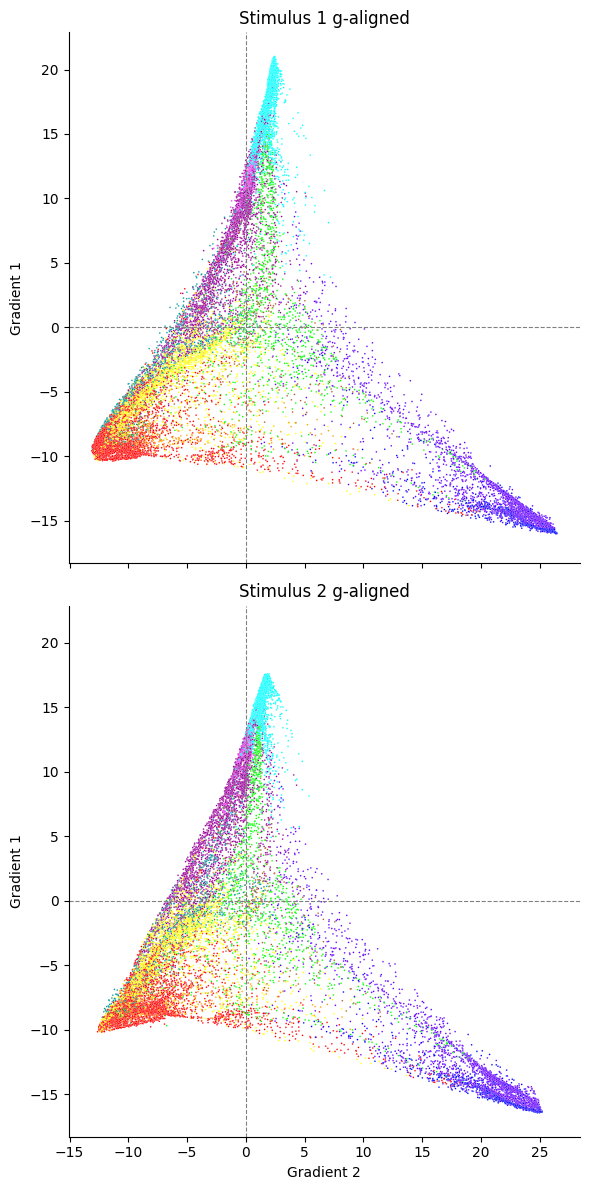

In [39]:
import numpy as np
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sub = 'All'
stimuli_types = ['1', '2']
spec = 'g-aligned'  # gradients

# Create a dictionary mapping network names to colors
network_colors = {name: color for name, color in zip(CAatlas_names['Network Name'], ca_cmap.colors[1:])}

# Placeholder for results
correlation_results = {}

# Create subplots for each stimulus
fig, axs = plt.subplots(len(stimuli_types), 1, figsize=(6, 12), sharex=True, sharey=True)

for i, stimulus in enumerate(stimuli_types):  # Use enumerate to get the index (i) and stimulus name
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stimulus}_betas.npy'))

        # Extract the first two rows (Gradient 1 and Gradient 2)
        grad1 = gradients[0, :]  # First row: Gradient 1
        grad2 = gradients[1, :]  # Second row: Gradient 2

        # Create a DataFrame for plotting
        df = pd.DataFrame({
            'Gradient 1': grad1,
            'Gradient 2': grad2,
            'ca_network': caNets_fsav5_mapping  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Scatter plot of Gradient 1 vs Gradient 2
        sns.scatterplot(data=df, x='Gradient 2', y='Gradient 1', hue='ca_network_name', 
                        palette=network_colors, s=1.4, legend=False, ax=axs[i])
        axs[i].set(title=f'Stimulus {stimulus} {spec}', xlabel='Gradient 2', ylabel='Gradient 1')
        axs[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axs[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

# Adjust layout and remove spines
plt.tight_layout()
sns.despine()
plt.show()

Processing comparison: Stimulus 1 vs stimulus reference_grad...
Correlation Matrix for 1 vs reference_grad:
[[0.84987484 0.42559056 0.05010926 0.24661903 0.03502965]
 [0.30446613 0.84149631 0.2583851  0.29463453 0.07136854]
 [0.21876794 0.13506821 0.21151142 0.59020044 0.69098061]
 [0.16545882 0.10132641 0.76452934 0.42850219 0.22247237]
 [0.24879068 0.19035171 0.32329036 0.35419297 0.52642362]]


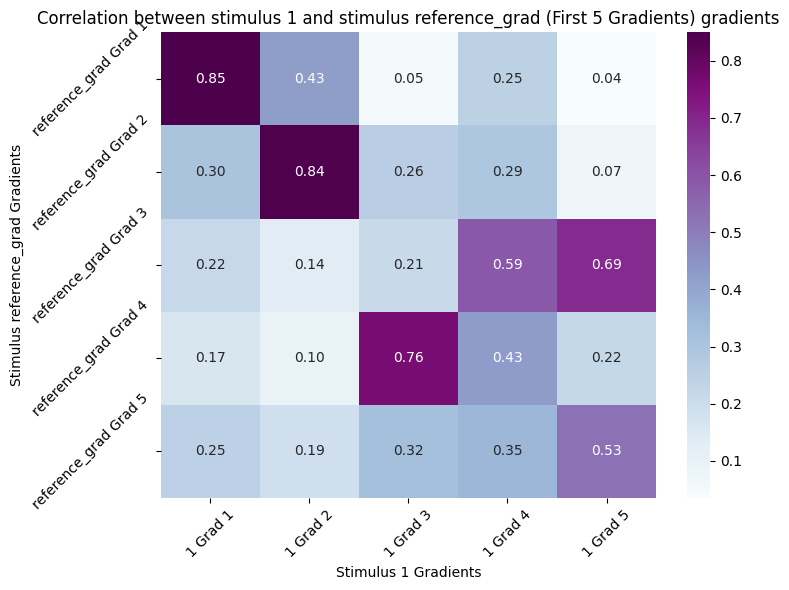

Processing comparison: Stimulus 2 vs stimulus reference_grad...
Correlation Matrix for 2 vs reference_grad:
[[0.83548761 0.45074435 0.1045663  0.24087861 0.0643412 ]
 [0.30895894 0.83865827 0.23889649 0.32701824 0.01779364]
 [0.23291336 0.21280007 0.24131007 0.6573403  0.59539173]
 [0.1525107  0.1243084  0.80398921 0.40335502 0.20028271]
 [0.2651612  0.20497583 0.36804236 0.35641503 0.63312875]]


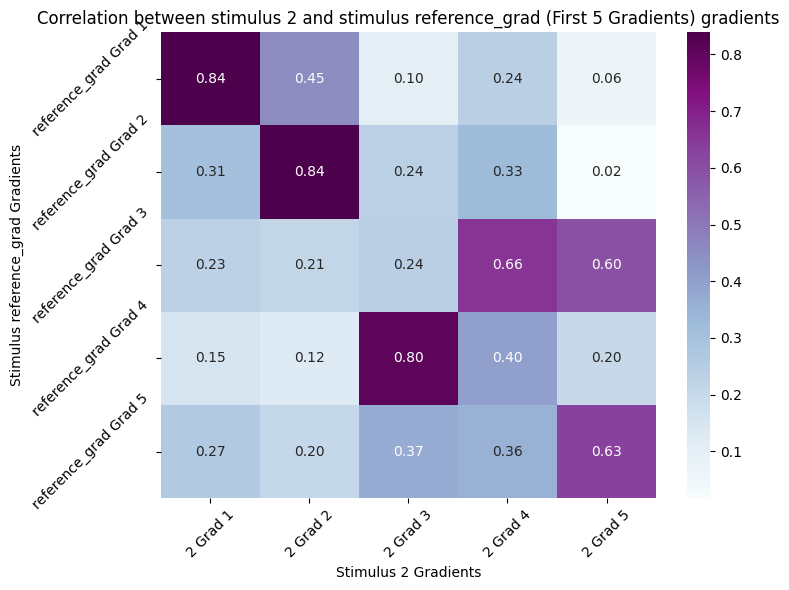

In [40]:
# correlation matrices between unaligned gradients and whole task gradients

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt


# Parameters
sub = 'All'
spec = 'gradients' 
stimuli_pairs = [
    ('1', 'reference_grad'),
    ('2', 'reference_grad')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: Stimulus {stim1} vs stimulus {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}_betas.npy')
    grad2_file = op.join(bids_folder_subjects,'derivatives', 'gradients','sub-All/sub-All_gradients_N-10.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients

    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between stimulus {stim1} and stimulus {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"Stimulus {stim1} Gradients")
    plt.ylabel(f"Stimulus {stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
# two-sample t-tests between network positions of stim 1 and stim 2 on the first gradient (because auditory network has this shift)

import numpy as np
import os
import os.path as op
import pandas as pd

sub = 'All'
stimuli_types = ['1', '2']
spec = 'gradients'

# Directory to save the DataFrames
output_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle')

for stimulus in stimuli_types:
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stimulus}_betas.npy'))

        # Extract the first two rows (Gradient 1 and Gradient 2)
        grad1 = gradients[0, :]  # First row: Gradient 1
        #grad2 = gradients[1, :]  # Second row: Gradient 2

        # Create a DataFrame
        df = pd.DataFrame({
            'Gradient 1': grad1,
            #'Gradient 2': grad2,
            'ca_network': caNets_fsav5_mapping  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Save the DataFrame to a CSV file
        output_file = op.join(output_dir, f'{stimulus}_dataframe.csv')
        df.to_csv(output_file, index=False)
        print(f'Saved DataFrame for {stimulus} to {output_file}')

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

Processing 1...
Saved DataFrame for 1 to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/1_dataframe.csv
Processing 2...
Saved DataFrame for 2 to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/2_dataframe.csv


In [12]:
# t-test to compare network positions between inverted stimulus_1 and stimulus_2

import pandas as pd
from scipy.stats import ttest_ind
import os.path as op


# Load the saved DataFrames for stimulus_1 and remaining
stim1_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 'stimulus_1_dataframe.csv'))
stim2_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 'stimulus_2_dataframe.csv'))

# Initialize a dictionary to store t-test results
t_test_results = {}

# Initialize a list to document rows with NaN values
nan_rows_log = []

# Perform two-sample t-tests for each network
for network in stim1_df['ca_network_name'].unique():
    # Filter data for the current network and convert to DataFrame
    stim1_values = stim1_df[stim1_df['ca_network_name'] == network][['Gradient 1']]
    stim2_values = stim2_df[stim2_df['ca_network_name'] == network][['Gradient 1']]
    
    # Identify rows with NaN values in either DataFrame
    stim1_nan_rows = stim1_values[stim1_values.isna().any(axis=1)].index.tolist()
    stim2_nan_rows = stim2_values[stim2_values.isna().any(axis=1)].index.tolist()
    
    # Log rows with NaN values
    if stim1_nan_rows:
        nan_rows_log.append({'network': network, 'dataframe': 'stimulus_1', 'rows': stim1_nan_rows})
    if stim2_nan_rows:
        nan_rows_log.append({'network': network, 'dataframe': 'stimulus_2', 'rows': stim2_nan_rows})

    # Drop rows with NaN values
    stim1_values = stim1_values.dropna()
    stim2_values = stim2_values.dropna()

    # Perform the t-test if both groups have sufficient data
    if len(stim1_values) > 1 and len(stim2_values) > 1:
        t_stat, p_value = ttest_ind(stim1_values['Gradient 1'], stim2_values['Gradient 1'], equal_var=False)
    else:
        t_stat, p_value = float('nan'), float('nan')

    # Perform a two-sample t-test
    t_stat, p_value = ttest_ind(stim1_values, stim2_values, equal_var=False)  # Welch's t-test
    
    # Store the results
    t_test_results[network] = {'t_stat': t_stat, 'p_value': p_value}

# Convert results to a DataFrame for easier visualization
t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index')
t_test_results_df.index.name = 'Network'
t_test_results_df.reset_index(inplace=True)

# Add a column to indicate significance (e.g., p < 0.05)
t_test_results_df['Significant'] = t_test_results_df['p_value'] < 0.05

# Print the results
print(t_test_results_df)

# Save the results to a CSV file
output_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 't_test_results_stim_1_stim_2.csv')
t_test_results_df.to_csv(output_file, index=False)
print(f'T-test results saved to {output_file}')

# Save the log of NaN rows to a CSV file
nan_log_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 'nan_rows_log.csv')
pd.DataFrame(nan_rows_log).to_csv(nan_log_file, index=False)
print(f'NaN rows log saved to {nan_log_file}')

                 Network                  t_stat                    p_value  \
0            Somatomotor    [28.020810107182026]  [1.7206726132801797e-161]   
1                Visual2     [2.078444447491566]      [0.03772786528257145]   
2      Cingulo-Opercular  [-0.33191676278883864]       [0.7399641518483446]   
3         Frontoparietal    [-4.101685260834969]    [4.164741130700901e-05]   
4                Visual1    [1.0642735295348242]       [0.2873901454701676]   
5                    NaN                   [nan]                      [nan]   
6               Language   [-2.4605851271642787]     [0.013950729532497942]   
7     Ventral-Multimodal    [-1.738780542379899]       [0.0825778991009151]   
8       Dorsal-attention   [0.08710403775595615]       [0.9305956073724087]   
9                Default   [-14.600473924570682]    [1.469670858303379e-47]   
10              Auditory   [-0.7957837240809688]       [0.4263366057593295]   
11  Posterior-Multimodal   [-0.3247539578544348]    

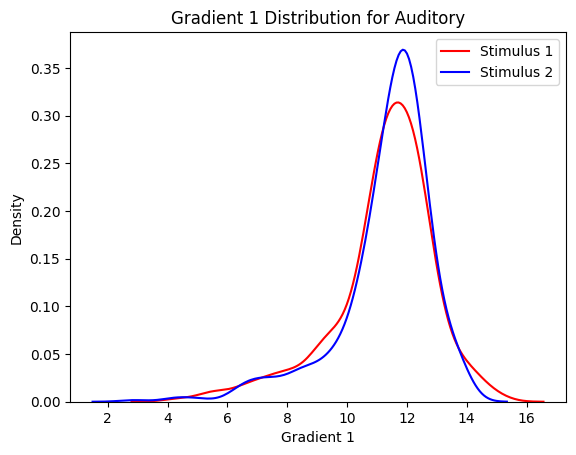

In [13]:
net_name = 'Auditory'
sns.kdeplot(stim1_df[stim1_df['ca_network_name'] == net_name]['Gradient 1'], label='Stimulus 1', color='red')
sns.kdeplot(stim2_df[stim2_df['ca_network_name'] == net_name]['Gradient 1'], label='Stimulus 2', color='blue')
plt.title(f'Gradient 1 Distribution for {net_name}')
plt.legend()